# Task 1: Article-Type Classification


## Experimental scope and candidate reuse

This isolated copy compares the existing CNN filter alternatives and adds MLP architectures. Production files remain unchanged.

| Family | Existing architecture reference | New alternatives |
|---|---|---|
| Shallow MLP | Dense(256), lower learning rate | Dense(64); Dense(128) |
| Deeper MLP | Dense(256, 128, 64), lower learning rate | Dense(128, 64, 32); Dense(256, 128) |
| CNN | Filters 32, 64, 128, 256 | Existing narrow, capped and wider filter experiments |

New MLP candidates retain the 96 ? 128 RGB input, dropout 0.2, training-only horizontal flips, unweighted loss, seed 2753 and batch 64. Shallow models use Adam 1e-4 and deeper models use Adam 3e-4, with a 20-epoch maximum and early-stopping patience 4. Compare architectural changes against the corresponding lower-learning-rate reference, not a differently trained original candidate. The compact deeper network changes width; the two-layer network changes depth.

Before every fit, check `models-test/<target>_<method>.keras`. Existing candidates are reloaded with their saved histories; missing candidates alone are trained. Hash, architecture, label order and normalization checks prevent accidental reuse of mismatched files. An existing model with missing or inconsistent companion files stops with an error rather than silently retraining. No optimizer resume is needed because existing files contain completed restored-best weights.

There are now 16 candidates per target: four shallow MLPs, four deeper MLPs and eight CNNs. With all previous candidates present, only four new MLP fits per target are needed (16 total across four targets). Missing previous candidates will also train. No existing CNN file is retrained. Comparisons, calibration of the new overall winner and selected exports are regenerated in the test folders. Internal-test metrics must not guide selection. Nothing is automatically promoted to production.


## 1. Introduction

This notebook addresses **Task 1: Article-Type Classification** for Assignment 2 by predicting the article type of a fashion product from its RGB image, such as a shirt, dress, or pair of shoes. The task is formulated as **a multi-class image classification problem: each image receives one catalogue article-type label**.

Three neural-network approaches are developed and trained from scratch using TensorFlow/Keras:

- **Shallow MLP (Baseline):** A fully connected network with one 256-unit hidden layer operating on flattened image pixels.
- **Deeper MLP:** A fully connected network with hidden layers of 256, 128, and 64 units, using dropout to reduce overfitting.
- **Convolutional Neural Network (CNN):** A spatial model that learns local image patterns through convolutional layers. The CNN family includes three declared architecture/scheduling configurations.

Performance is assessed using:

- **Accuracy:** The proportion of correctly classified images.
- **Macro-F1:** The primary selection metric, giving equal weight to the F1 scores of classes present in the evaluation partition.
- **Per-class classification reports and confusion matrices:** Evidence of which labels are recognized reliably and which are confused.
- **Learning curves:** Training and validation loss, accuracy, and macro-F1 used to examine convergence and overfitting.
- **Calibration metrics:** Confidence reliability of the selected model, assessed after selection using separate validation groups.

Article categories can share silhouettes and textures, while rare categories have fewer training examples. The analysis therefore considers class support and common confusions alongside overall accuracy.

The workflow covers metadata inspection, preprocessing, model development, comparative evaluation, selection, and export for prediction. All candidates use the same frozen group-isolated data partitions. The internal test has prior development exposure, which remains a limitation after retraining. Numerical findings and the final model judgment must be completed from the new executed results; no winner is assumed in advance.


## 2. Library Imports & Setup

Use the Fashion Keras kernel. The seed controls initialization and augmentation. Float32 is used throughout; GPU availability is reported before models are created.


In [1]:
from pathlib import Path
import sys, json, os, hashlib
from concurrent.futures import ThreadPoolExecutor
ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'scripts' / 'preprocessing.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the fashion-intelligence-classification repository.')
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, log_loss, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from scipy.optimize import minimize_scalar
import tensorflow as tf
from tensorflow import keras
from scripts.preprocessing import task_frame, IMAGE_SIZE, NORMALISATION_PATH, SEED, select_tensorflow_device
DEVICE = select_tensorflow_device()
if not tf.config.list_physical_devices('GPU') and os.environ.get('FASHION_TEST_ALLOW_CPU') != '1':
    raise RuntimeError('No TensorFlow GPU found. Use the WSL Fashion Keras environment; allow CPU explicitly with FASHION_TEST_ALLOW_CPU=1.')
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
OUTPUT, RESULTS, FIGURES = (ROOT / 'models-test', ROOT / 'results-test', ROOT / 'figures-test')
for directory in (OUTPUT, RESULTS, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)
MAX_EPOCHS, BATCH_SIZE = (30, 64)

def stem_for(target):
    return 'article_type' if target == 'articleType' else target
# False for a fresh Run All. Enable only when deliberately resuming matching saved experiments.
RESUME_SAVED_RESULTS = False

get_ipython().run_line_magic('matplotlib', 'inline')


2026-09-11 19:16:57.589025: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-11 19:16:57.625846: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-11 19:16:58.503776: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0: /GPU:0


## 3. Load Metadata

Load valid labelled images and their frozen split assignments. Inspect paths, target labels and missing values before preprocessing.


In [2]:
metadata_by_target = {'articleType': task_frame('articleType')}
frame = metadata_by_target['articleType']
print('articleType', frame.shape)
display(frame.head())


articleType (38611, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


## 4. Data Preprocessing

Prepare the same images and label encoding for every candidate. Preserve group isolation and fit normalization on training data only.


### 4.1. Class Distribution & Balancing Strategy

Preserve the original sample distribution. Initial candidates use unweighted cross-entropy; additional CNN experiments compare this with capped square-root inverse-frequency weights computed only from training counts. No examples are duplicated, and validation metrics remain unweighted.


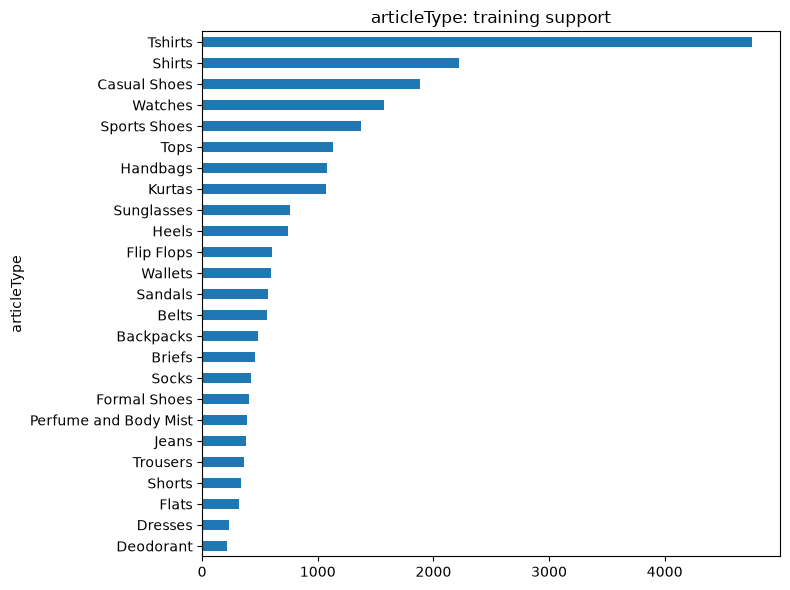

In [3]:
train_rows = metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('train')]
counts = train_rows['articleType'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'articleType'}: training support")
plt.tight_layout()
plt.show()


### 4.2. Training, Validation & Test Partitions

Reuse the frozen product-group split. Within validation, use separate groups for selection, temperature fitting and policy checking. Do not use the internal test to select candidates.


In [4]:
def validation_views(frame):
    selection_ids, rest_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
                                   .split(frame, groups=frame.group_key))
    selection, rest = frame.iloc[selection_ids], frame.iloc[rest_ids]
    cal_ids, policy_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED + 1)
                              .split(rest, groups=rest.group_key))
    return selection, rest.iloc[cal_ids], rest.iloc[policy_ids]


In [5]:
frames, labels_by_target = ({}, {})
selection, calibration, policy = validation_views(metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('validation')])
frames['articleType'] = dict(train=metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('train')], selection=selection, calibration=calibration, policy=policy)
groups = [set(frame.group_key) for frame in frames['articleType'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1:]))
labels_by_target['articleType'] = sorted(frames['articleType']['train']['articleType'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['articleType'].items()}, name='articleType'))


train          27051
selection       2900
calibration     1378
policy          1564
Name: articleType, dtype: int64

### 4.3. Image Preprocessing

Resize RGB to 96 x 128 pixels (width x height), then normalize using training-only channel statistics. The batch class stores decoded uint8 images and converts one batch at a time to float32. Horizontal flips are applied inside each model only during training.


In [6]:
class CachedBatches(keras.utils.PyDataset):
    """Decode RGB once to uint8 RAM, then normalize each NHWC batch."""
    def __init__(self, frame, target, labels, normalisation, training=False, batch_size=64):
        super().__init__(workers=0, max_queue_size=2)
        self.dataset = frame
        self.training, self.batch_size = training, batch_size
        def read(path):
            with Image.open(path) as image:
                return np.asarray(image.convert("RGB").resize(IMAGE_SIZE, Image.Resampling.BILINEAR)).copy()
        with ThreadPoolExecutor(max_workers=4) as pool:
            self.images = np.stack(list(pool.map(read, frame.image_path)))
        self.targets = np.asarray([labels.index(label) for label in frame[target]], dtype=np.int32)
        self.mean = np.asarray(normalisation["mean"], dtype=np.float32)
        self.std = np.asarray(normalisation["std"], dtype=np.float32)
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(SEED)
        self.indices = np.arange(len(self.dataset))
        if self.training:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def __getitem__(self, index):
        ids = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        images = self.images[ids].astype(np.float32) / 255.0
        return (images - self.mean) / self.std, self.targets[ids]

    def on_epoch_end(self):
        if self.training:
            self.rng.shuffle(self.indices)


### 4.4. Feature Batches & Label Encoding

Map sorted label names to integer indices, preserving the same order for every model. Construct shuffled training batches and fixed-order selection batches.


In [7]:
normalisation = json.loads(NORMALISATION_PATH.read_text())
loaders = {}
labels = labels_by_target['articleType']
loaders['articleType'] = {name: CachedBatches(frames['articleType'][name], 'articleType', labels, normalisation, training=name == 'train', batch_size=BATCH_SIZE) for name in ['train', 'selection']}


## 5. Model Development & Evaluation

This section develops three neural-network families trained from scratch on the supplied fashion images. Moving from flattened pixels to deeper dense layers and then spatial convolutions lets us examine how architecture affects performance under the same evaluation protocol.

**Models included:**

- **5.1. Shallow MLP (Baseline):** Establishes the performance of one hidden layer on flattened RGB input.
- **5.2. Deeper MLP:** Tests whether additional dense layers improve the learned representation and generalization.
- **5.3. Convolutional Neural Network (CNN):** Learns spatial features and compares the declared convolutional configurations and learning-rate schedules.

Each model subsection shows its architecture, compilation, and training code. All candidates use the same image size, normalization, batch size, training/selection groups, Adam optimizer, and maximum epoch budget. Training-only horizontal flips and dropout provide regularization. Early stopping restores the epoch with the highest selection macro-F1; scheduled CNNs additionally reduce the learning rate when that metric stalls.

The following subsections compare the restored models, plot learning curves, and evaluate the selected model. Model selection prioritizes **validation macro-F1**, then accuracy, then parameter count. Calibration and review thresholds use separate validation groups. The internal test is evaluated after selection and must not be used to choose an architecture.


### Evaluation Metric: Macro-F1

Accumulate the full-epoch confusion matrix and average F1 over classes with positive ground-truth support. This metric selects the restored epoch and winning model. It does not average per-batch F1 scores.

The displayed per-class classification report also includes every output label for coverage auditing. Its standard `macro avg` row therefore includes zero-support output labels and can differ from the supported-class macro-F1 used for selection. Read the explicitly reported selection metric for model ranking, and inspect support before making claims about all classes. Selection support is 97/124 article types, 4/4 seasons, 5/5 gender categories and 8/9 occasion labels for this frozen run.


In [8]:
@keras.utils.register_keras_serializable(package="Fashion")
class SupportedMacroF1(keras.metrics.Metric):
    """Macro-F1 over classes present in the full epoch's ground truth."""
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.matrix = self.add_weight(name="matrix", shape=(num_classes, num_classes), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        truth = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        predictions = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        weights = None if sample_weight is None else tf.cast(tf.reshape(sample_weight, [-1]), self.dtype)
        self.matrix.assign_add(tf.math.confusion_matrix(truth, predictions, self.num_classes,
                                                        weights=weights, dtype=self.dtype))

    def result(self):
        support = tf.reduce_sum(self.matrix, axis=1)
        predicted = tf.reduce_sum(self.matrix, axis=0)
        f1 = tf.math.divide_no_nan(2 * tf.linalg.diag_part(self.matrix), support + predicted)
        mask = tf.cast(support > 0, self.dtype)
        return tf.math.divide_no_nan(tf.reduce_sum(f1 * mask), tf.reduce_sum(mask))

    def reset_state(self):
        self.matrix.assign(tf.zeros_like(self.matrix))

    def get_config(self):
        return {**super().get_config(), "num_classes": self.num_classes}


### Saved-Model Metadata

An identity layer stores label order, preprocessing and confidence policy inside each exported Keras model.


In [9]:
@keras.utils.register_keras_serializable(package="Fashion")
class ModelMetadata(keras.layers.Layer):
    """Store label order, preprocessing and calibration inside the .keras file."""
    def __init__(self, metadata=None, **kwargs):
        super().__init__(**kwargs)
        self.metadata = dict(metadata or {})

    def call(self, inputs):
        return inputs

    def get_config(self):
        return {**super().get_config(), "metadata": dict(self.metadata)}


### Export Every Experimental Candidate

Save restored weights immediately after each fit so a later interruption does not discard completed candidates. Exports contain inference weights without optimizer storage; resuming training requires rerunning that candidate.


In [10]:
def export_candidate(target, method):
    """Save every restored candidate immediately, without optimizer slots."""
    model = models[target][method]
    metadata = dict(
        target=target, labels=labels_by_target[target], model_type=method,
        temperature=1.0, mean=normalisation['mean'], std=normalisation['std'],
        image_size=list(IMAGE_SIZE), experiment_scope='filter_comparison',
        calibration_status='uncalibrated_candidate', seed=SEED,
    )
    exported = keras.models.clone_model(model)
    exported.set_weights(model.get_weights())
    exported.get_layer('metadata').metadata = metadata
    path = OUTPUT / f'{stem_for(target)}_{method}.keras'
    exported.save(path)
    history = histories[target][method]
    history.to_csv(RESULTS / f'{stem_for(target)}_{method}_history.csv', index=False)
    configuration = dict(
        target=target, method=method, model_file=path.name,
        model_sha256=hashlib.sha256(path.read_bytes()).hexdigest(),
        architecture=json.loads(exported.to_json()),
        optimizer=keras.optimizers.serialize(model.optimizer),
        seed=SEED, batch_size=BATCH_SIZE, epochs_run=len(history),
        best_epoch=int(history['val_macro_f1'].to_numpy().argmax()) + 1,
        tensorflow_version=tf.__version__, keras_version=keras.__version__,
        candidate_calibrated=False,
    )
    (RESULTS / f'{stem_for(target)}_{method}_configuration.json').write_text(
        json.dumps(configuration, indent=2, default=lambda value: value.item()) + '\n')
    print('Saved candidate:', path, flush=True)


def reuse_candidate(target, method):
    """Reuse an existing export; never silently retrain an invalid existing file."""
    path = OUTPUT / f'{stem_for(target)}_{method}.keras'
    if not path.exists():
        print('TRAIN missing candidate:', path.name, flush=True)
        return False
    history_path = RESULTS / f'{stem_for(target)}_{method}_history.csv'
    config_path = RESULTS / f'{stem_for(target)}_{method}_configuration.json'
    if not history_path.is_file() or not config_path.is_file():
        raise RuntimeError(f'Existing {path.name} needs its history/configuration restored; refusing to retrain it.')
    record = json.loads(config_path.read_text())
    if hashlib.sha256(path.read_bytes()).hexdigest() != record['model_sha256']:
        raise RuntimeError(f'Hash mismatch for {path.name}; refusing to overwrite or retrain it.')
    restored = keras.models.load_model(path, compile=False)
    metadata = restored.get_layer('metadata').metadata
    assert metadata['target'] == target and metadata['model_type'] == method
    assert metadata['labels'] == labels_by_target[target]
    assert metadata['image_size'] == list(IMAGE_SIZE)
    np.testing.assert_allclose(metadata['mean'], normalisation['mean'])
    np.testing.assert_allclose(metadata['std'], normalisation['std'])
    expected = models[target][method]
    def signature(model):
        return [(type(layer).__name__, getattr(layer, 'units', None), getattr(layer, 'filters', None), getattr(layer, 'kernel_size', None), getattr(layer, 'rate', None)) for layer in model.layers]
    if signature(restored) != signature(expected):
        raise RuntimeError(f'Architecture differs for {path.name}; use a new candidate name.')
    history = pd.read_csv(history_path)
    required = {'loss', 'accuracy', 'macro_f1', 'val_loss', 'val_accuracy', 'val_macro_f1'}
    if history.empty or not required.issubset(history.columns) or len(history) != record['epochs_run']:
        raise RuntimeError(f'Incomplete history for {path.name}; refusing to retrain an existing model.')
    models[target][method] = restored
    histories[target][method] = history.drop(columns=['epoch'], errors='ignore')
    print('REUSE saved candidate:', path.name, flush=True)
    return True


In [11]:
models = {'articleType': {}}
histories = {'articleType': {}}


### 5.1. Shallow MLP (Baseline)


The shallow MLP is the baseline for this experiment. It learns combinations of flattened pixel values through one hidden layer but has no convolutional mechanism for local spatial patterns. Its measured performance provides the reference for the deeper models.


#### 5.1.1. Model Architecture

Flatten the image and use one 256-unit hidden layer as the baseline. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.


In [12]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
models['articleType']['shallow_mlp'] = keras.Sequential(layers, name='shallow_mlp')
models['articleType']['shallow_mlp'].summary()


I0000 00:00:1789129080.228243  316643 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "shallow_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,469,308 (36.12 MB)

 Trainable params: 9,469,308 (36.12 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.


In [13]:
model = models['articleType']['shallow_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])


#### 5.1.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.


In [14]:
loaders['articleType']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
if not reuse_candidate('articleType', 'shallow_mlp'):
    fitted = models['articleType']['shallow_mlp'].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
    histories['articleType']['shallow_mlp'] = pd.DataFrame(fitted.history)
    export_candidate('articleType', 'shallow_mlp')
display(histories['articleType']['shallow_mlp'].tail())


REUSE saved candidate: article_type_shallow_mlp.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
25,0.628369,1.422579,0.242340,0.661724,4.390100,0.262202
26,0.628332,1.576056,0.233096,0.671724,2.982040,0.280479
27,0.624117,2.006891,0.219700,0.657586,4.223036,0.266122
28,0.635097,1.451572,0.234706,0.636207,5.514629,0.231386
29,0.621530,1.755447,0.227021,0.638276,5.808415,0.232390


#### 5.1.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


articleType shallow_mlp


selection_accuracy    0.671724
selection_macro_f1    0.280479
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,0.909091,0.833333,0.869565,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.833333,0.740741,0.784314,54.000000
Bangle,0.000000,0.000000,0.000000,13.000000
Basketballs,0.000000,0.000000,0.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.671724,0.671724,0.671724,0.671724
macro avg,0.236340,0.222199,0.219407,2900.000000


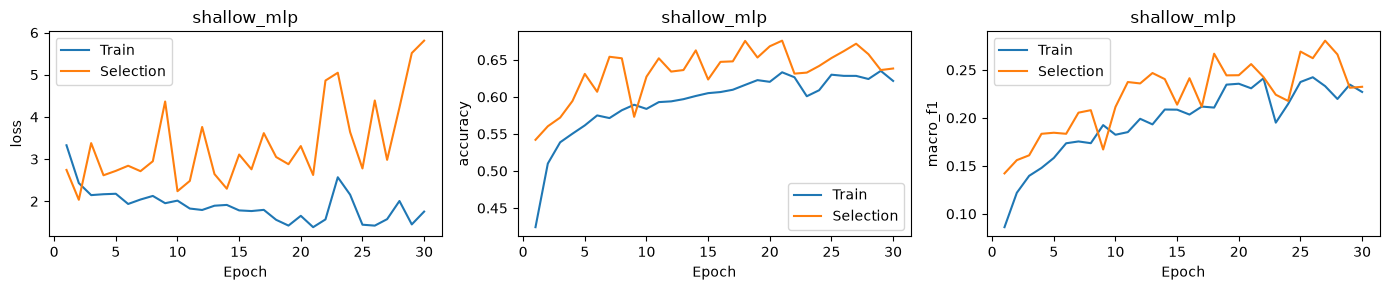

In [15]:
loader = loaders['articleType']['selection']
for method in ['shallow_mlp']:
    model = models['articleType'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('articleType', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    history = histories['articleType'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
    plt.show()


#### 5.1.5. Evaluation Analysis

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


### 5.2. Deeper MLP


The deeper MLP processes the same flattened RGB input through three hidden layers. ReLU activations allow successive nonlinear transformations, while dropout reduces reliance on individual activations. Compare its validation metrics and learning-curve gap with the shallow baseline before concluding that depth is useful.


#### 5.2.1. Model Architecture

Flatten the image and use three hidden layers to test whether additional nonlinear transformations improve generalization. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.


In [16]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256, 128, 64]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
models['articleType']['deeper_mlp'] = keras.Sequential(layers, name='deeper_mlp')
models['articleType']['deeper_mlp'].summary()


Model: "deeper_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 124)            │         8,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,486,652 (36.19 MB)

 Trainable params: 9,486,652 (36.19 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.


In [17]:
model = models['articleType']['deeper_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])


#### 5.2.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.


In [18]:
loaders['articleType']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
if not reuse_candidate('articleType', 'deeper_mlp'):
    fitted = models['articleType']['deeper_mlp'].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
    histories['articleType']['deeper_mlp'] = pd.DataFrame(fitted.history)
    export_candidate('articleType', 'deeper_mlp')
display(histories['articleType']['deeper_mlp'].tail())


REUSE saved candidate: article_type_deeper_mlp.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
18,0.662822,1.155732,0.203221,0.690345,1.078258,0.264425
19,0.666112,1.134315,0.210075,0.680690,1.110584,0.272139
20,0.664929,1.142532,0.211707,0.697931,1.081789,0.266125
21,0.665521,1.148533,0.208609,0.674138,1.100471,0.266353
22,0.671879,1.105124,0.217446,0.681035,1.100453,0.256522


#### 5.2.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


articleType deeper_mlp


selection_accuracy    0.701379
selection_macro_f1    0.285285
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,0.833333,0.909091,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.803571,0.833333,0.818182,54.000000
Bangle,1.000000,0.153846,0.266667,13.000000
Basketballs,0.000000,0.000000,0.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.701379,0.701379,0.701379,0.701379
macro avg,0.248449,0.240459,0.223166,2900.000000


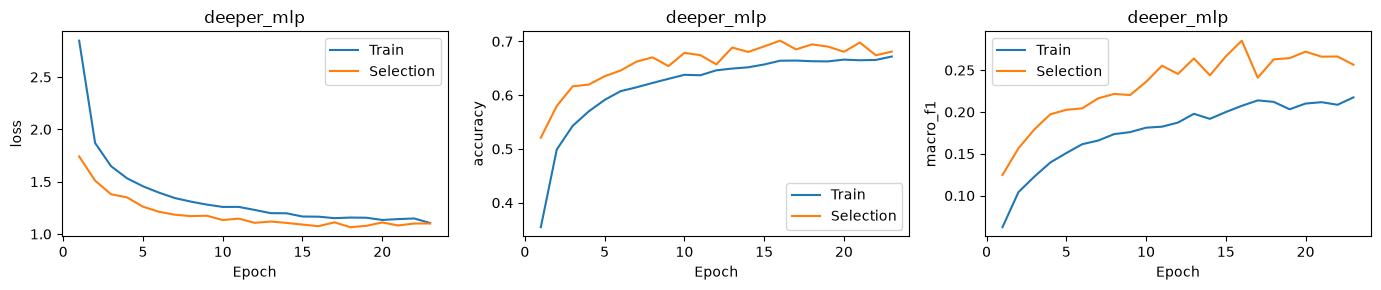

In [19]:
loader = loaders['articleType']['selection']
for method in ['deeper_mlp']:
    model = models['articleType'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('articleType', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    history = histories['articleType'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
    plt.show()


#### 5.2.5. Evaluation Analysis

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


### 5.3. Convolutional Neural Network (CNN)

Six initial CNN configurations compare depth, scheduling and filter width. All remain members of the CNN family. The filter-only comparison uses the four scheduled four-block architectures.


#### 5.3.1. Model Architecture

Retain the two three-block controls and compare the four-block reference with narrow, capped-final-block and wider-final-block variants. All four-block candidates keep the same Dense(256) head and training recipe.


In [20]:
CNN_CONFIGS = {'cnn_ordinary': ((32, 64, 128), 128, False), 'cnn_scheduled': ((32, 64, 128), 128, True), 'cnn_four_blocks_scheduled': ((32, 64, 128, 256), 256, True), 'cnn_narrow_scheduled': ((16, 32, 64, 128), 256, True), 'cnn_capped_scheduled': ((32, 64, 128, 128), 256, True), 'cnn_wide_scheduled': ((32, 64, 128, 384), 256, True)}
for method, (channels, hidden, scheduled) in CNN_CONFIGS.items():
    keras.utils.set_random_seed(SEED)
    layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal')]
    for width in channels:
        layers.extend([keras.layers.Conv2D(width, 3, padding='same'), keras.layers.BatchNormalization(), keras.layers.Activation('relu'), keras.layers.MaxPooling2D(2)])
    h, w = (IMAGE_SIZE[1] // 2 ** len(channels), IMAGE_SIZE[0] // 2 ** len(channels))
    layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten(), keras.layers.Dense(hidden, activation='relu'), keras.layers.Dropout(0.2), keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
    models['articleType'][method] = keras.Sequential(layers, name=method)
    models['articleType'][method].summary()


Model: "cnn_ordinary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 2, 2, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 124)            │        15,996 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,804 (686.73 KB)

 Trainable params: 175,356 (684.98 KB)

 Non-trainable params: 448 (1.75 KB)

...

Model: "cnn_wide_scheduled"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 12, 384)    │       442,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 16, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 2, 2, 384)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 963,772 (3.68 MB)

 Trainable params: 962,556 (3.67 MB)

 Non-trainable params: 1,216 (4.75 KB)

#### 5.3.2. Compile the CNN Models

Keep optimizer, loss and metrics the same as the MLPs so the comparison tests architecture and the declared schedule.


In [21]:
for method in CNN_CONFIGS:
    models['articleType'][method].compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])


#### 5.3.3. Train and Tune the CNN Models

Scheduled variants halve the learning rate after two epochs without improvement. All variants stop after seven stale epochs. Selection data controls these decisions; test data is not read here.


In [22]:
for method, (_, _, scheduled) in CNN_CONFIGS.items():
    loaders['articleType']['train'].reset()
    callbacks = []
    if scheduled:
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2))
    callbacks.append(keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True))
    if not reuse_candidate('articleType', method):
        fitted = models['articleType'][method].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=MAX_EPOCHS, callbacks=callbacks, shuffle=False, verbose=2)
        histories['articleType'][method] = pd.DataFrame(fitted.history)
        export_candidate('articleType', method)
    display(histories['articleType'][method].tail())


REUSE saved candidate: article_type_cnn_ordinary.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
17,0.813242,0.574737,0.507965,0.767931,0.781653,0.436120
18,0.814683,0.563136,0.518018,0.782414,0.806706,0.443333
19,0.819674,0.555750,0.547370,0.784483,0.733027,0.467605
20,0.821855,0.542518,0.549626,0.742414,0.914260,0.425986
21,0.824886,0.530818,0.558773,0.741035,0.928966,0.367388


REUSE saved candidate: article_type_cnn_scheduled.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1,learning_rate
25,0.849802,0.448151,0.633064,0.821724,0.620162,0.548213,0.00025
26,0.852760,0.441498,0.630340,0.829310,0.592465,0.577082,0.00025
27,0.852871,0.440898,0.634924,0.824138,0.596773,0.535149,0.00025
28,0.855052,0.434243,0.631766,0.833448,0.586918,0.591687,0.00025
29,0.856234,0.433135,0.617696,0.829655,0.577536,0.552852,0.00025


REUSE saved candidate: article_type_cnn_four_blocks_scheduled.keras


...

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1,learning_rate
25,0.927212,0.214127,0.854949,0.856207,0.536496,0.620560,0.000125
26,0.927840,0.208795,0.835532,0.857931,0.534746,0.639327,0.000125
27,0.929171,0.206353,0.832979,0.853103,0.526599,0.621041,0.000125
28,0.932905,0.199138,0.873203,0.855172,0.552283,0.625209,0.000125
29,0.934716,0.190302,0.865028,0.860345,0.532673,0.644447,0.000063


REUSE saved candidate: article_type_cnn_capped_scheduled.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1,learning_rate
23,0.931130,0.206087,0.820580,0.866207,0.491882,0.608220,0.000063
24,0.932720,0.204523,0.838109,0.865517,0.494736,0.606104,0.000063
25,0.934494,0.196614,0.828491,0.864483,0.485468,0.618261,0.000031
26,0.934531,0.196350,0.799077,0.866207,0.489588,0.608132,0.000031
27,0.937045,0.190706,0.831280,0.866207,0.482868,0.626361,0.000016


REUSE saved candidate: article_type_cnn_wide_scheduled.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1,learning_rate
21,0.920816,0.236346,0.770340,0.866897,0.484432,0.602915,0.000031
22,0.921260,0.237693,0.766390,0.862759,0.484338,0.589227,0.000031
23,0.923958,0.230667,0.755834,0.867586,0.486610,0.586191,0.000016
24,0.923515,0.229032,0.760228,0.866897,0.484754,0.586801,0.000016
25,0.923958,0.227627,0.767704,0.868276,0.483856,0.588446,0.000008


#### 5.3.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


2026-09-11 19:18:05.986302: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92501


articleType cnn_ordinary


selection_accuracy    0.780345
selection_macro_f1    0.472314
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.859649,0.907407,0.882883,54.000000
Bangle,1.000000,0.076923,0.142857,13.000000
Basketballs,1.000000,1.000000,1.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.780345,0.780345,0.780345,0.780345
macro avg,0.430979,0.372699,0.369472,2900.000000


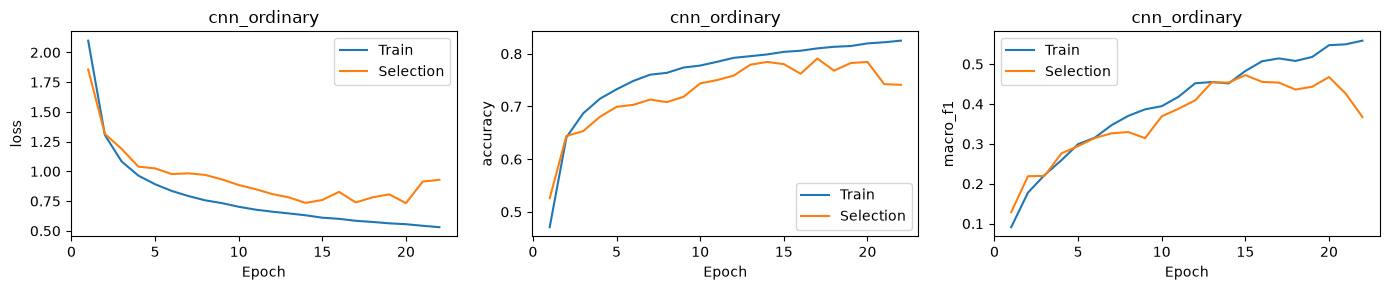

articleType cnn_scheduled


selection_accuracy    0.833448
selection_macro_f1    0.591687
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.940000,0.870370,0.903846,54.000000
Bangle,0.500000,0.153846,0.235294,13.000000
Basketballs,1.000000,1.000000,1.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.833448,0.833448,0.833448,0.833448
macro avg,0.503009,0.461021,0.462852,2900.000000


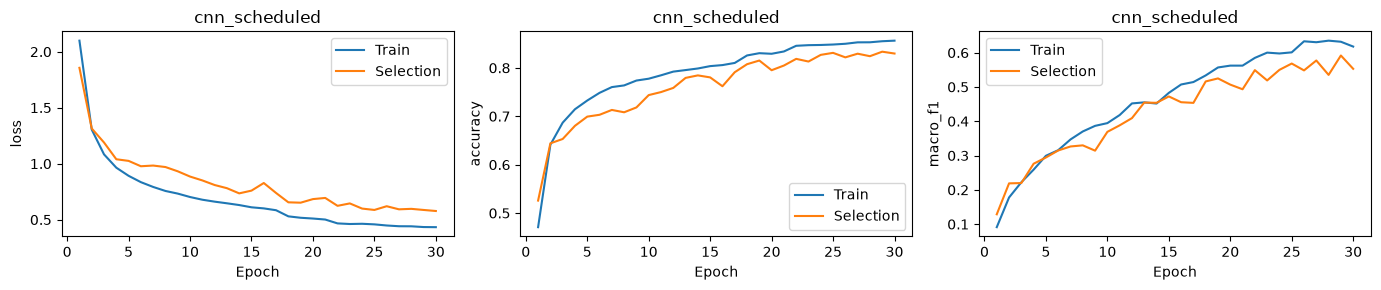

articleType cnn_four_blocks_scheduled


selection_accuracy    0.871034
selection_macro_f1    0.666445
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.961538,0.925926,0.943396,54.000000
Bangle,0.500000,0.153846,0.235294,13.000000
Basketballs,1.000000,0.333333,0.500000,3.000000
...,...,...,...,...
Water Bottle,1.000000,1.000000,1.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.871034,0.871034,0.871034,0.871034
macro avg,0.543383,0.526087,0.521332,2900.000000


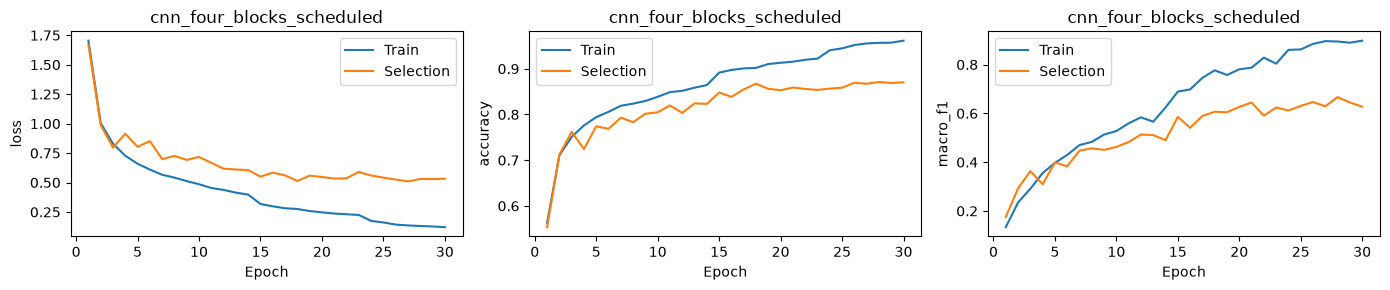

articleType cnn_narrow_scheduled


selection_accuracy    0.860345
selection_macro_f1    0.644447
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.942308,0.907407,0.924528,54.000000
Bangle,0.750000,0.230769,0.352941,13.000000
Basketballs,1.000000,1.000000,1.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.860345,0.860345,0.860345,0.860345
macro avg,0.530891,0.502684,0.504124,2900.000000


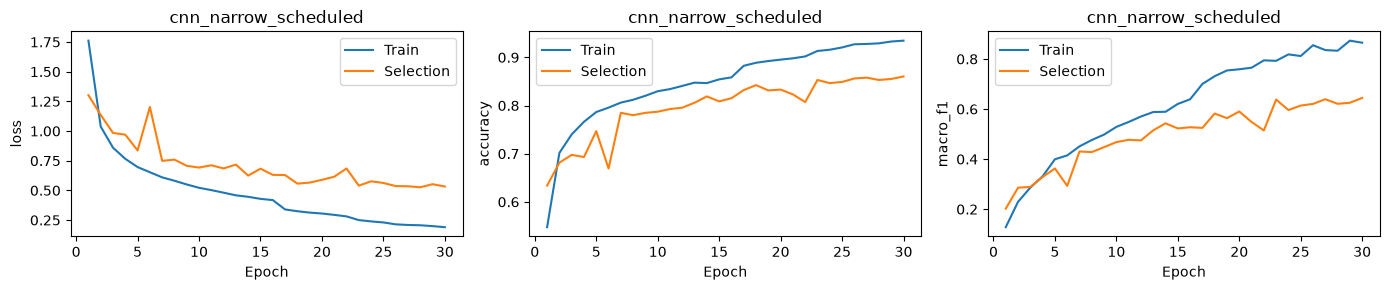

articleType cnn_capped_scheduled


selection_accuracy    0.86000
selection_macro_f1    0.62647
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,12.00
Baby Dolls,0.000000,0.000000,0.000000,0.00
Backpacks,0.980392,0.925926,0.952381,54.00
Bangle,0.666667,0.307692,0.421053,13.00
Basketballs,1.000000,0.333333,0.500000,3.00
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.00
Wristbands,0.000000,0.000000,0.000000,0.00
accuracy,0.860000,0.860000,0.860000,0.86
macro avg,0.520408,0.496487,0.490061,2900.00


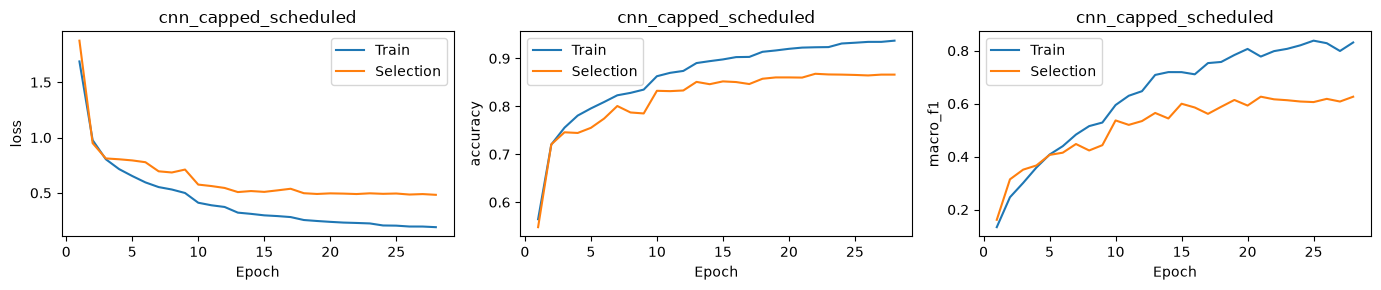

articleType cnn_wide_scheduled


selection_accuracy    0.864138
selection_macro_f1    0.605848
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.960784,0.907407,0.933333,54.000000
Bangle,0.500000,0.153846,0.235294,13.000000
Basketballs,1.000000,0.666667,0.800000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.864138,0.864138,0.864138,0.864138
macro avg,0.498080,0.475511,0.473929,2900.000000


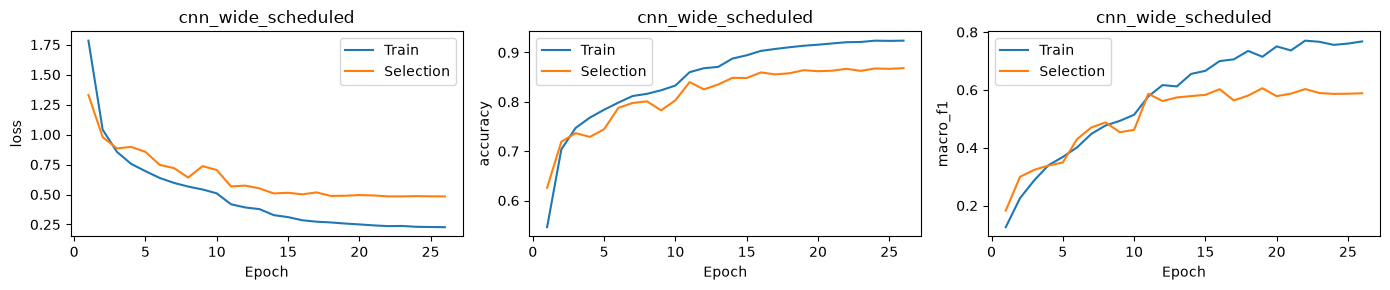

In [23]:
loader = loaders['articleType']['selection']
for method in list(CNN_CONFIGS):
    model = models['articleType'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('articleType', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    history = histories['articleType'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
    plt.show()


#### 5.3.5. Evaluation Analysis

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


#### 5.3.6. Target-specific parameter tuning

The completed first run motivates lower learning rates for the unstable MLPs and a short CNN continuation with and without class weighting. These are additional candidates, not assumed improvements. Only training counts determine weights; selection macro-F1 chooses the winner. Calibration, policy and internal-test images are excluded from fitting.

Both CNN candidates start from identical selected CNN weights. Their shared learning rate, dropout, seed and epoch budget isolate the effect of class weights. Each MLP keeps its original architecture and uses a lower learning rate for up to 20 epochs. CNN continuation uses up to 8 additional epochs; its history records additional epochs only.

This experimental Run All reloads completed candidates and trains only missing ones. RESUME_SAVED_RESULTS remains False to prevent mixing earlier results with this run. Both continuation candidates use the fresh four-block reference, regardless of which filter alternative wins.


**articleType: configure candidates and training-only weights.** Normalize square-root inverse-frequency weights to mean one over training examples, then cap them at 4 to limit the influence of extremely rare labels. Validation metrics remain unweighted.


In [24]:
PARAMETER_CONFIGS_articleType = {
    'shallow_mlp_lower_lr': dict(family='shallow_mlp', learning_rate=1e-4, epochs=20, weighted=False),
    'deeper_mlp_lower_lr': dict(family='deeper_mlp', learning_rate=3e-4, epochs=20, weighted=False),
    'cnn_continue': dict(family='cnn', learning_rate=3e-05, epochs=8, weighted=False),
    'cnn_continue_weighted': dict(family='cnn', learning_rate=3e-05, epochs=8, weighted=True),
    'shallow_mlp_64': dict(family='shallow_mlp', widths=[64], learning_rate=1e-4, epochs=20, weighted=False),
    'shallow_mlp_128': dict(family='shallow_mlp', widths=[128], learning_rate=1e-4, epochs=20, weighted=False),
    'deeper_mlp_compact': dict(family='deeper_mlp', widths=[128, 64, 32], learning_rate=3e-4, epochs=20, weighted=False),
    'deeper_mlp_two_layers': dict(family='deeper_mlp', widths=[256, 128], learning_rate=3e-4, epochs=20, weighted=False),
}
counts = np.bincount(loaders['articleType']['train'].targets, minlength=len(labels_by_target['articleType']))
assert (counts > 0).all()
weights = np.sqrt(counts.sum() / (len(counts) * counts))
weights = np.clip(weights / np.average(weights, weights=counts), 0.25, 4)
class_weights_articleType = {i: float(value) for i, value in enumerate(weights)}
if 'cnn_four_blocks_scheduled' in models['articleType']:
    tuning_source_articleType = models['articleType']['cnn_four_blocks_scheduled']
else:
    tuning_source_articleType = keras.models.load_model(OUTPUT / f"{stem_for('articleType')}_model.keras", compile=False)
    saved_metadata = tuning_source_articleType.get_layer('metadata').metadata
    assert saved_metadata['target'] == 'articleType' and saved_metadata['labels'] == labels_by_target['articleType']
    assert saved_metadata['model_type'].startswith('cnn')
    assert saved_metadata['image_size'] == list(IMAGE_SIZE)
    np.testing.assert_allclose(saved_metadata['mean'], normalisation['mean'])
    np.testing.assert_allclose(saved_metadata['std'], normalisation['std'])
    models['articleType'][saved_metadata['model_type']] = tuning_source_articleType
for method, config in PARAMETER_CONFIGS_articleType.items():
    keras.utils.set_random_seed(SEED)
    if config['family'] == 'cnn':
        candidate = keras.models.clone_model(tuning_source_articleType)
        candidate.set_weights(tuning_source_articleType.get_weights())
        candidate.get_layer('metadata').metadata = {}
    else:
        widths = config.get('widths', [256] if config['family'] == 'shallow_mlp' else [256, 128, 64])
        layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
        for width in widths:
            layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
        layers.extend([keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
        candidate = keras.Sequential(layers, name=method)
    candidate.compile(optimizer=keras.optimizers.Adam(config['learning_rate']), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])
    models['articleType'][method] = candidate
pd.DataFrame(PARAMETER_CONFIGS_articleType).T.to_csv(RESULTS / f"{stem_for('articleType')}_parameter_configs.csv")
display(pd.DataFrame(PARAMETER_CONFIGS_articleType).T)


,family,learning_rate,epochs,weighted,widths
shallow_mlp_lower_lr,shallow_mlp,0.0001,20,False,NaN
deeper_mlp_lower_lr,deeper_mlp,0.0003,20,False,NaN
cnn_continue,cnn,0.00003,8,False,NaN
cnn_continue_weighted,cnn,0.00003,8,True,NaN
shallow_mlp_64,shallow_mlp,0.0001,20,False,[64]
shallow_mlp_128,shallow_mlp,0.0001,20,False,[128]
deeper_mlp_compact,deeper_mlp,0.0003,20,False,"[128, 64, 32]"
deeper_mlp_two_layers,deeper_mlp,0.0003,20,False,"[256, 128]"


**articleType: fit the additional candidates.** Early stopping restores the best selection macro-F1. Paired CNN runs reset random state and batch ordering. Class weights affect training loss only ([Keras training API](https://keras.io/api/models-test/model_training_apis/)).


In [25]:
for method, config in PARAMETER_CONFIGS_articleType.items():
    keras.utils.set_random_seed(SEED)
    loaders['articleType']['train'].reset()
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True)]
    print('articleType', method, flush=True)
    if not reuse_candidate('articleType', method):
        fitted = models['articleType'][method].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=config['epochs'], callbacks=callbacks, class_weight=class_weights_articleType if config['weighted'] else None, shuffle=False, verbose=2)
        histories['articleType'][method] = pd.DataFrame(fitted.history)
        export_candidate('articleType', method)
    histories['articleType'][method].to_csv(RESULTS / f"{stem_for('articleType')}_{method}_history.csv", index=False)
    display(histories['articleType'][method].tail())


articleType shallow_mlp_lower_lr


REUSE saved candidate: article_type_shallow_mlp_lower_lr.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
10,0.758234,0.818638,0.421727,0.742069,0.997930,0.443202
11,0.768622,0.774652,0.445689,0.750345,1.034931,0.408948
12,0.768548,0.772791,0.448236,0.744483,1.047561,0.420783
13,0.771912,0.769787,0.451919,0.752414,0.967691,0.410947
14,0.780119,0.711641,0.475364,0.757931,0.996487,0.436796


articleType deeper_mlp_lower_lr


REUSE saved candidate: article_type_deeper_mlp_lower_lr.keras


...

423/423 - 9s - 22ms/step - accuracy: 0.7233 - loss: 0.9056 - macro_f1: 0.3265 - val_accuracy: 0.7179 - val_loss: 0.9428 - val_macro_f1: 0.3544


Epoch 20/20


423/423 - 9s - 22ms/step - accuracy: 0.7245 - loss: 0.9158 - macro_f1: 0.3383 - val_accuracy: 0.7324 - val_loss: 0.9279 - val_macro_f1: 0.3783


Saved candidate: /mnt/d/khoile/programs/fashion-intelligence-classification/models-test/article_type_deeper_mlp_two_layers.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
15,0.715870,0.953375,0.312831,0.732414,0.931094,0.351420
16,0.719678,0.928082,0.312733,0.726552,0.949170,0.365093
17,0.717792,0.930399,0.318370,0.730000,0.947627,0.362846
18,0.723263,0.905598,0.326479,0.717931,0.942752,0.354420
19,0.724483,0.915766,0.338334,0.732414,0.927909,0.378301


**articleType: evaluate on selection images.** The final comparison keeps the best candidate within each family. Rare-class recall accompanies overall scores; continuation is retained only if it wins the declared ranking.


In [26]:
loader = loaders['articleType']['selection']
for method in PARAMETER_CONFIGS_articleType:
    probabilities = np.vstack([tf.nn.softmax(models['articleType'][method](loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(1)
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    display(pd.Series(dict(method=method, accuracy=accuracy_score(loader.targets, predictions), macro_f1=f1_score(loader.targets, predictions, labels=np.unique(loader.targets), average='macro', zero_division=0))))


method      shallow_mlp_lower_lr
accuracy                0.742069
macro_f1                0.443202
dtype: object

method      deeper_mlp_lower_lr
accuracy               0.718621
macro_f1                0.31603
dtype: object

method      cnn_continue
accuracy        0.870345
macro_f1        0.664806
dtype: object

method      cnn_continue_weighted
accuracy                     0.87
macro_f1                 0.695401
dtype: object

method      shallow_mlp_64
accuracy          0.724138
macro_f1          0.374179
dtype: object

method      shallow_mlp_128
accuracy           0.741379
macro_f1           0.431195
dtype: object

method      deeper_mlp_compact
accuracy               0.69931
macro_f1              0.241174
dtype: object

method      deeper_mlp_two_layers
accuracy                 0.732414
macro_f1                 0.378301
dtype: object

### 5.4. Model Comparison

Choose the best configuration within each of the three families using selection macro-F1, then accuracy, then fewer parameters. Original runs and the additional parameter experiments are compared on the same selection partition. The three-row table reports family winners; the experiments CSV retains candidate-level evidence.


In [27]:
def supported_macro_f1(truth, predictions) -> float:
    """Macro-average over labels present in the ground-truth partition."""
    return float(f1_score(
        truth, predictions, labels=np.unique(truth), average="macro", zero_division=0
    ))

def expected_calibration_error(
    truth: np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    """Compute top-label expected calibration error."""
    truth = np.asarray(truth)
    probabilities = np.asarray(probabilities)
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == truth
    edges = np.linspace(0.0, 1.0, bins + 1)
    total = len(truth)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:], strict=True):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            error += selected.sum() / total * abs(
                float(correct[selected].mean()) - float(confidence[selected].mean())
            )
    return float(error)

def ranked(table):
    """Predeclared: macro F1, then accuracy, then fewer parameters."""
    return table.sort_values(['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
                             ascending=[False, False, True], kind='stable')


In [28]:
comparisons, tuning, winners, checkpoints = ({}, {}, {}, {})
rows = []
loader = loaders['articleType']['selection']
for method, model in models['articleType'].items():
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    rows.append(dict(method=method, validation_accuracy=accuracy_score(loader.targets, probabilities.argmax(1)), validation_macro_f1=supported_macro_f1(loader.targets, probabilities.argmax(1)), validation_ece=expected_calibration_error(loader.targets, probabilities), complexity_parameters=model.count_params(), epochs_run=len(histories['articleType'][method])))
experiments = pd.DataFrame(rows).set_index('method')
# Resume measured candidates whose weights were not exported after kernel shutdown.
previous_path = RESULTS / f"{stem_for('articleType')}_experiments.csv"
if RESUME_SAVED_RESULTS and previous_path.exists():
    previous = pd.read_csv(previous_path, index_col='method')
    experiments = pd.concat([previous.loc[~previous.index.isin(experiments.index)], experiments])
experiments.to_csv(RESULTS / f"{stem_for('articleType')}_experiments.csv")
tuning['articleType'] = experiments.loc[experiments.index.str.startswith('cnn')].copy()
for metric in ['accuracy', 'macro_f1']:
    tuning['articleType'][f'{metric}_change_vs_ordinary'] = tuning['articleType'][f'validation_{metric}'] - tuning['articleType'].loc['cnn_ordinary', f'validation_{metric}']
best_cnn = ranked(tuning['articleType']).index[0]
best_shallow = ranked(experiments.loc[experiments.index.str.startswith('shallow_mlp')]).index[0]
best_deeper = ranked(experiments.loc[experiments.index.str.startswith('deeper_mlp')]).index[0]
table = experiments.loc[[best_shallow, best_deeper, best_cnn]].copy()
table['family'] = ['shallow_mlp', 'deeper_mlp', 'cnn']
winners['articleType'] = ranked(table).index[0]
table['selected'] = table.index == winners['articleType']
comparisons['articleType'] = table
table.to_csv(RESULTS / f"{stem_for('articleType')}_comparison.csv")
tuning['articleType'].to_csv(RESULTS / f"{stem_for('articleType')}_cnn_tuning.csv")
display(table)
display(tuning['articleType'])
assert winners['articleType'] in models['articleType'], 'Winning weights are missing; retrain that candidate before export.'


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,family,selected
method,,,,,,,
shallow_mlp_lower_lr,0.742069,0.443202,0.026717,9469308,15,shallow_mlp,False
deeper_mlp_two_layers,0.732414,0.378301,0.015553,9486332,20,deeper_mlp,False
cnn_continue_weighted,0.870000,0.695401,0.040363,684604,8,cnn,True


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary
method,,,,,,,
cnn_ordinary,0.780345,0.472314,0.018076,175804,22,0.000000,0.000000
cnn_scheduled,0.833448,0.591687,0.017734,175804,30,0.053103,0.119373
cnn_four_blocks_scheduled,0.871034,0.666445,0.039313,684604,30,0.090690,0.194131
cnn_narrow_scheduled,0.860345,0.644447,0.035497,261596,30,0.080000,0.172133
cnn_capped_scheduled,0.860000,0.626470,0.020106,405436,28,0.079655,0.154156
cnn_wide_scheduled,0.864138,0.605848,0.026137,963772,26,0.083793,0.133534
cnn_continue,0.870345,0.664806,0.050317,684604,8,0.090000,0.192492
cnn_continue_weighted,0.870000,0.695401,0.040363,684604,8,0.089655,0.223086


#### Filter-only comparison

Compare only equally trained four-block CNNs here. Gains are relative to the fresh reference run, not the separately continued production winner.


In [29]:
filter_methods = ['cnn_four_blocks_scheduled', 'cnn_narrow_scheduled', 'cnn_capped_scheduled', 'cnn_wide_scheduled']
filter_table = tuning['articleType'].loc[filter_methods].copy()
reference = filter_table.loc['cnn_four_blocks_scheduled']
filter_table['macro_f1_change_vs_reference'] = filter_table.validation_macro_f1 - reference.validation_macro_f1
filter_table['accuracy_change_vs_reference'] = filter_table.validation_accuracy - reference.validation_accuracy
filter_table = ranked(filter_table)
filter_table.to_csv(RESULTS / f"{stem_for('articleType')}_filter_comparison.csv")
display(filter_table)


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary,macro_f1_change_vs_reference,accuracy_change_vs_reference
method,,,,,,,,,
cnn_four_blocks_scheduled,0.871034,0.666445,0.039313,684604,30,0.090690,0.194131,0.000000,0.000000
cnn_narrow_scheduled,0.860345,0.644447,0.035497,261596,30,0.080000,0.172133,-0.021998,-0.010690
cnn_capped_scheduled,0.860000,0.626470,0.020106,405436,28,0.079655,0.154156,-0.039975,-0.011034
cnn_wide_scheduled,0.864138,0.605848,0.026137,963772,26,0.083793,0.133534,-0.060598,-0.006897


#### MLP architecture comparisons

Each family uses the lower-learning-rate reference with the same training budget. These tables isolate architectural changes from learning-rate changes.


In [30]:

all_scores = pd.read_csv(RESULTS / f"{stem_for('articleType')}_experiments.csv", index_col='method')
for family, methods in {'shallow_mlp': ['shallow_mlp_lower_lr', 'shallow_mlp_64', 'shallow_mlp_128'], 'deeper_mlp': ['deeper_mlp_lower_lr', 'deeper_mlp_compact', 'deeper_mlp_two_layers']}.items():
    architecture_table = all_scores.loc[methods].copy()
    architecture_table['macro_f1_change_vs_reference'] = architecture_table.validation_macro_f1 - architecture_table.iloc[0].validation_macro_f1
    architecture_table = ranked(architecture_table)
    architecture_table.to_csv(RESULTS / f"{stem_for('articleType')}_{family}_architecture_comparison.csv")
    display(architecture_table)


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,macro_f1_change_vs_reference
method,,,,,,
shallow_mlp_lower_lr,0.742069,0.443202,0.026717,9469308,15,0.000000
shallow_mlp_128,0.741379,0.431195,0.045410,4734716,20,-0.012007
shallow_mlp_64,0.724138,0.374179,0.031960,2367420,16,-0.069023


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,macro_f1_change_vs_reference
method,,,,,,
deeper_mlp_two_layers,0.732414,0.378301,0.015553,9486332,20,0.062271
deeper_mlp_lower_lr,0.718621,0.316030,0.042619,9486652,18,0.000000
deeper_mlp_compact,0.699310,0.241174,0.065901,4733148,20,-0.074856


### 5.5. Learning Curves

Inspect the restored best epoch and later trajectory rather than the final epoch alone. Training enables augmentation and dropout; selection uses inference mode, so a negative training-minus-selection accuracy gap is possible.

The class-weighted CNN uses weighted training loss but unweighted validation loss. Their raw loss gap does not directly measure overfitting. Accuracy and supported-class macro-F1 remain unweighted and are comparable across candidates, subject to the training/inference-mode difference. CNN continuation plots count additional epochs from the shared starting checkpoint.


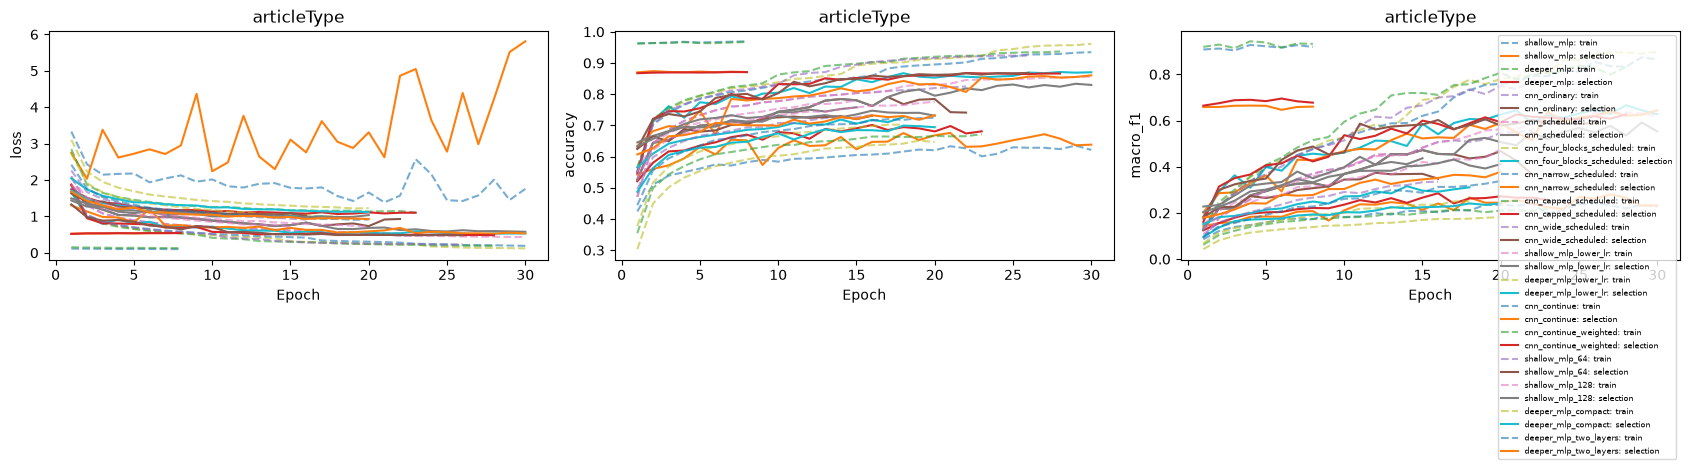

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for method, history in histories['articleType'].items():
    history = history.copy()
    history.insert(0, 'epoch', np.arange(1, len(history) + 1))
    history.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_history.csv", index=False)
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(history.epoch, history[metric], linestyle='--', alpha=0.6, label=f'{method}: train')
        ax.plot(history.epoch, history[f'val_{metric}'], label=f'{method}: selection')
        ax.set(xlabel='Epoch', ylabel=metric, title='articleType')
axes[-1].legend(fontsize=6)
fig.tight_layout()
fig.savefig(FIGURES / f"{stem_for('articleType')}_learning_curves.png", dpi=160)
plt.show()


### 5.6. Model Evaluation & Error Analysis

The following small inference helpers reproduce application preprocessing. Temperature scaling changes confidence, not the predicted class. Calibration is fitted on separate groups, then accepted only if policy-group NLL improves without worsening ECE.


#### 5.6.1. Prepare one inference image

Use the same RGB resizing and training-only normalization as the training batches.


In [32]:
def image_batch(image, image_size, mean, std):
    resized = image.convert("RGB").resize(tuple(image_size), Image.Resampling.BILINEAR)
    array = np.asarray(resized, dtype=np.float32) / 255.0
    array = (array - np.asarray(mean, dtype=np.float32)) / np.asarray(std, dtype=np.float32)
    return array[None, ...]


#### 5.6.2. Rescale confidence

Divide log probabilities by a positive temperature and renormalize.


In [33]:
def temperature_scale(probabilities, temperature=1.0):
    """Rescale confidence without changing the highest-probability class."""
    if not np.isfinite(temperature) or temperature <= 0:
        raise ValueError('Temperature must be finite and positive')
    values = np.asarray(probabilities, dtype=np.float64)
    if values.ndim < 1 or values.shape[-1] == 0 or (not np.isfinite(values).all()) or (values < 0).any():
        raise ValueError('Probabilities must be finite, nonnegative vectors')
    mass = values.sum(axis=-1, keepdims=True)
    if (mass <= 0).any():
        raise ValueError('Probability vectors must have positive mass')
    values = values / mass
    if temperature == 1.0:
        return values
    logits = np.log(np.clip(values, np.finfo(np.float64).tiny, 1.0)) / temperature
    logits -= logits.max(axis=-1, keepdims=True)
    scaled = np.exp(logits)
    return scaled / scaled.sum(axis=-1, keepdims=True)


#### 5.6.3. Notebook prediction interface

Use the same logits, labels and review-policy semantics as the web application. This class performs inference only.


In [34]:
class FashionClassifier:
    def __init__(self, checkpoint_path, device=None):
        checkpoint = checkpoint_path if isinstance(checkpoint_path, dict) else load_checkpoint(checkpoint_path)
        self.device = "/CPU:0" if device == "cpu" else (device if device and str(device).startswith("/") else None)
        self.target, self.labels = checkpoint["target"], list(checkpoint["labels"])
        self.temperature = float(checkpoint.get("temperature", 1.0))
        self.review_policy = checkpoint.get("review_policy")
        self.model_type = checkpoint["model_type"]
        self.model = checkpoint.get("model")
        self.members = None
        if self.model is not None:
            self.mean, self.std = checkpoint["mean"], checkpoint["std"]
            self.image_size = checkpoint["image_size"]
            self.estimator = self.feature_config = None
        else:
            raise ValueError("Classifier has no trained Keras model")

    def predict_batch(self, inputs):
        with tf.device(self.device):
            probabilities = tf.nn.softmax(self.model(inputs, training=False), axis=-1).numpy()
        return temperature_scale(probabilities, self.temperature)

    def predict_probabilities(self, image):
        inputs = image_batch(image, self.image_size, self.mean, self.std)
        return self.predict_batch(inputs)[0]

    def predict(self, image: Image.Image, top_k: int = 3) -> dict:
        if top_k < 1:
            raise ValueError("top_k must be positive")
        probabilities = self.predict_probabilities(image)
        count = min(top_k, len(self.labels))
        indices = np.argsort(probabilities)[::-1][:count]
        ranked = [
            {"label": self.labels[int(index)], "confidence": float(probabilities[index])}
            for index in indices
        ]
        result = {
            "target": self.target,
            "label": ranked[0]["label"],
            "confidence": ranked[0]["confidence"],
            "top_k": ranked,
        }
        if self.review_policy is not None:
            threshold = self.review_policy['threshold']
            result['needs_review'] = threshold is None or ranked[0]['confidence'] < threshold
            result['review_threshold'] = threshold
            result['confidence_calibrated'] = self.temperature != 1.0
            if self.review_policy.get('brightness_stability') and not result['needs_review']:
                stable_label = int(indices[0])
                unstable = any(
                    int(self.predict_probabilities(ImageEnhance.Brightness(image.convert('RGB')).enhance(factor)).argmax()) != stable_label
                    for factor in (0.8, 1.2)
                )
                if unstable:
                    result['needs_review'] = True
                    result['review_reason'] = 'Prediction changes with lighting'
        return result


#### 5.6.4. Evaluate a partition

Compute accuracy, supported-class macro-F1, ECE, NLL and Brier score. Record sampled batch/single-image differences as a diagnostic; large differences or changed predictions warn, while invalid probabilities raise an error.


In [35]:
def evaluate_saved_checkpoint(checkpoint_path, frame, device="cpu", batch_size=64):
    """Re-evaluate a frozen artifact with the application's exact preprocessing.

    This never fits a model or changes its checkpoint. Batching changes only
    execution and may slightly affect floating-point scores; label ordering
    and saved temperature match the web API.
    """
    from sklearn.metrics import log_loss

    if frame.empty:
        raise ValueError("Evaluation requires at least one image")
    predictor = FashionClassifier(checkpoint_path, device=device)
    labels = predictor.labels
    truth = np.asarray([labels.index(label) for label in frame[predictor.target]])
    batches = []
    for start in range(0, len(frame), batch_size):
        inputs = []
        for path in frame.image_path.iloc[start:start + batch_size]:
            with Image.open(path) as source:
                inputs.append(image_batch(source, predictor.image_size, predictor.mean, predictor.std))
        batches.append(predictor.predict_batch(np.concatenate(inputs)))
    probabilities = np.vstack(batches)
    if (probabilities.shape != (len(frame), len(labels))
            or not np.isfinite(probabilities).all()
            or (probabilities < 0).any()
            or not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5, rtol=1e-5)):
        raise ValueError("Batch inference returned invalid probabilities")
    predictions = probabilities.argmax(1)
    metrics = {
        "accuracy": float(accuracy_score(truth, predictions)),
        "macro_f1": supported_macro_f1(truth, predictions),
        "ece": expected_calibration_error(truth, probabilities),
        "nll": float(log_loss(truth, probabilities, labels=np.arange(len(labels)))),
        "brier": float(np.mean(np.sum((probabilities - np.eye(len(labels))[truth]) ** 2, axis=1))),
    }
    # Batch and single-image GPU kernels can produce slightly different scores.
    # Sample this difference as a diagnostic, not a requirement for calibration.
    # A 0.001 absolute difference means 0.1 percentage points of probability;
    # it is a warning threshold, not a guarantee of equivalent predictions.
    import warnings

    positions = sorted({0, len(frame) // 2, len(frame) - 1})
    max_absolute_difference = 0.0
    prediction_mismatches = []
    for position in positions:
        with Image.open(frame.image_path.iloc[position]) as source:
            single = np.asarray(predictor.predict_probabilities(source))
        if (single.shape != probabilities[position].shape
                or not np.isfinite(single).all()
                or (single < 0).any()
                or not np.isclose(single.sum(), 1.0, atol=1e-5, rtol=1e-5)):
            raise ValueError("Single-image inference returned invalid probabilities")
        difference = float(np.max(np.abs(probabilities[position] - single)))
        max_absolute_difference = max(max_absolute_difference, difference)
        if predictions[position] != single.argmax():
            prediction_mismatches.append(position)
    inference_consistency = {
        "sample_count": len(positions),
        "max_absolute_difference": max_absolute_difference,
        "prediction_mismatch_positions": prediction_mismatches,
    }
    if max_absolute_difference > 1e-3 or prediction_mismatches:
        warnings.warn(
            f"Batch/single-image inference diagnostic: {inference_consistency}. "
            "Evaluation and calibration use batched probabilities. Inspect these "
            "differences before interpreting single-image application results.",
            RuntimeWarning, stacklevel=2,
        )
    return {"labels": labels, "truth": truth, "predictions": predictions,
            "probabilities": probabilities, "metrics": metrics,
            "inference_consistency": inference_consistency}


#### 5.6.5. Fit temperature and the review threshold

Search temperature on calibration groups, then use policy groups to decide whether to keep it and when to request manual review.


In [36]:
def calibrate(checkpoint, calibration, policy, device):
    checkpoint = dict(checkpoint)
    cal = evaluate_saved_checkpoint(checkpoint, calibration, device=str(device))
    raw = evaluate_saved_checkpoint(checkpoint, policy, device=str(device))
    fit = minimize_scalar(lambda log_t: log_loss(
        cal['truth'], temperature_scale(cal['probabilities'], np.exp(log_t)),
        labels=np.arange(len(checkpoint['labels']))),
        bounds=(np.log(0.25), np.log(10)), method='bounded')
    temperature = float(np.exp(fit.x))
    scaled = temperature_scale(raw['probabilities'], temperature)
    if (log_loss(raw['truth'], scaled, labels=np.arange(len(checkpoint['labels']))) < raw['metrics']['nll']
            and expected_calibration_error(raw['truth'], scaled) <= raw['metrics']['ece']):
        checkpoint['temperature'] = temperature
    else:
        scaled = raw['probabilities']
    threshold = None
    for value in np.round(np.arange(0.50, 1.00, 0.01), 2):
        accepted = scaled.max(1) >= value
        if accepted.sum() >= 100 and np.mean(scaled.argmax(1)[accepted] == raw['truth'][accepted]) >= 0.90:
            threshold = float(value)
            break
    checkpoint['review_policy'] = {'threshold': threshold, 'target_accuracy': 0.90,
                                   'minimum_policy_samples': 100,
                                   'brightness_stability': checkpoint['target'] == 'articleType'}
    return checkpoint


In [37]:
method = winners['articleType']
checkpoints['articleType'] = dict(target='articleType', labels=labels_by_target['articleType'], model=models['articleType'][method], model_type=method, temperature=1.0, mean=normalisation['mean'], std=normalisation['std'], image_size=list(IMAGE_SIZE), comparison_row=comparisons['articleType'].loc[method].to_dict())
checkpoints['articleType'] = calibrate(checkpoints['articleType'], frames['articleType']['calibration'], frames['articleType']['policy'], DEVICE)


/tmp/ipykernel_316643/3233117733.py:3: RuntimeWarning: Batch/single-image inference diagnostic: {'sample_count': 3, 'max_absolute_difference': 0.001117754151516881, 'prediction_mismatch_positions': []}. Evaluation and calibration use batched probabilities. Inspect these differences before interpreting single-image application results.
  cal = evaluate_saved_checkpoint(checkpoint, calibration, device=str(device))


#### 5.6.6. Evaluate the selected model on the internal test

Do not revise the architecture based on this table. Report prior development exposure and inspect per-class support before interpreting overall accuracy.


In [38]:
test_results = {}
result = evaluate_saved_checkpoint(checkpoints['articleType'], metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('test')], device=DEVICE)
test_results['articleType'] = result
checkpoints['articleType']['test_metrics'] = result['metrics']
display(pd.Series(result['metrics'], name='articleType'))
report = classification_report(result['truth'], result['predictions'], labels=np.arange(len(result['labels'])), target_names=result['labels'], output_dict=True, zero_division=0)
display(pd.DataFrame(report).T)
pd.DataFrame(report).T.to_csv(RESULTS / f"{stem_for('articleType')}_test_per_class.csv")
pd.Series(result['metrics']).to_csv(RESULTS / f"{stem_for('articleType')}_test_metrics.csv")


/tmp/ipykernel_316643/3182551293.py:2: RuntimeWarning: Batch/single-image inference diagnostic: {'sample_count': 3, 'max_absolute_difference': 0.0010066871208317396, 'prediction_mismatch_positions': []}. Evaluation and calibration use batched probabilities. Inspect these differences before interpreting single-image application results.
  result = evaluate_saved_checkpoint(checkpoints['articleType'], metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('test')], device=DEVICE)


accuracy    0.863414
macro_f1    0.637272
ece         0.011648
nll         0.449771
brier       0.196899
Name: articleType, dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,18.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.880342,0.936364,0.907489,110.000000
Bangle,0.400000,1.000000,0.571429,2.000000
Basketballs,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...
Water Bottle,0.333333,0.500000,0.400000,2.000000
Wristbands,0.000000,0.000000,0.000000,1.000000
accuracy,0.863414,0.863414,0.863414,0.863414
macro avg,0.533299,0.528727,0.519068,5718.000000


#### 5.6.7. Confidence bins

Compare average confidence with actual accuracy within each bin. Low-support bins are less reliable.


In [39]:
def calibration_table(truth: np.ndarray, probabilities: np.ndarray) -> pd.DataFrame:
    """Return a ten-bin reliability table for notebook evidence."""
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == np.asarray(truth)
    frame = pd.DataFrame({"confidence": confidence, "correct": correct})
    frame["bin"] = pd.cut(
        frame.confidence, bins=np.linspace(0, 1, 11), include_lowest=True
    )
    return frame.groupby("bin", observed=False).agg(
        mean_confidence=("confidence", "mean"),
        accuracy=("correct", "mean"),
        samples=("correct", "size"),
    )


In [40]:
result = test_results['articleType']
display(calibration_table(result['truth'], result['probabilities']))


,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",0.188144,0.500000,6
"(0.2, 0.3]",0.267538,0.148936,47
"(0.3, 0.4]",0.357149,0.381679,131
"(0.4, 0.5]",0.454929,0.489362,235
"(0.5, 0.6]",0.546907,0.582656,369
"(0.6, 0.7]",0.650346,0.633588,393
"(0.7, 0.8]",0.751429,0.800971,412
"(0.8, 0.9]",0.855871,0.864434,627


#### 5.6.8. Confusion matrices

Rows are true labels and columns are predicted labels. The article-type plot groups uncommon predicted classes into an Other column for readability.


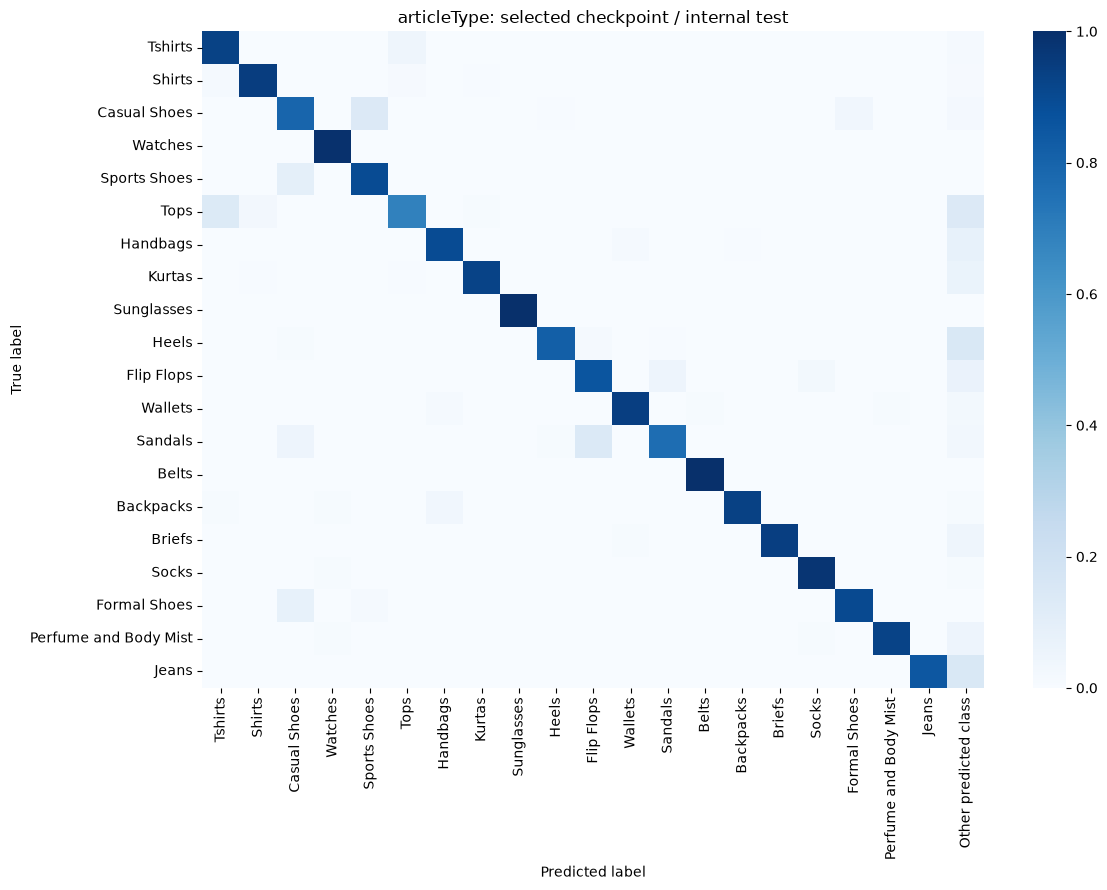

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
directory = RESULTS
stem = stem_for('articleType')
result = test_results['articleType']
labels = result['labels']
shown = task_frame('articleType', 'train')['articleType'].value_counts().head(20).index.tolist()
indices = [labels.index(label) for label in shown]
others = [i for i in range(len(labels)) if i not in indices]
matrix = confusion_matrix(result['truth'], result['predictions'], labels=np.arange(len(labels)))
counts = np.column_stack([matrix[indices][:, indices], matrix[indices][:, others].sum(1)])
normalized = counts / np.maximum(counts.sum(1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(normalized, xticklabels=shown + ['Other predicted class'], yticklabels=shown, cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set(xlabel='Predicted label', ylabel='True label')
ax.set_title(f"{'articleType'}: selected checkpoint / internal test")
fig.tight_layout()
fig.savefig(FIGURES / f'{stem}_confusion.png', dpi=160, bbox_inches='tight')
plt.show()


## 6. Ultimate Judgement

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


In [42]:
winner = comparisons['articleType'].loc[winners['articleType']]
baseline = comparisons['articleType'].loc[comparisons['articleType']['family'].eq('shallow_mlp')].iloc[0]
display(pd.Series({'selected_method': winners['articleType'], 'selection_macro_f1': winner.validation_macro_f1, 'selection_accuracy': winner.validation_accuracy, 'macro_f1_gain_over_baseline': winner.validation_macro_f1 - baseline.validation_macro_f1, 'internal_test_accuracy': test_results['articleType']['metrics']['accuracy'], 'internal_test_macro_f1': test_results['articleType']['metrics']['macro_f1']}, name='articleType'))


selected_method                cnn_continue_weighted
selection_macro_f1                          0.695401
selection_accuracy                              0.87
macro_f1_gain_over_baseline                 0.252199
internal_test_accuracy                      0.863414
internal_test_macro_f1                      0.637272
Name: articleType, dtype: object

### 6.1. Decision Analysis

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


## 7. Final Prediction

Save the selected model, reload it, and predict a sample image. Exported metadata allows the standalone prediction scripts and web application to apply the same preprocessing and confidence policy.


In [43]:
def save_checkpoint(checkpoint, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path = path.with_suffix(".keras")
    model = checkpoint["model"]
    metadata = {key: value for key, value in checkpoint.items() if key != "model"}
    metadata = json.loads(json.dumps(metadata, default=lambda value: value.item()))
    model.get_layer("metadata").metadata = metadata
    # Export architecture, learned weights and metadata without optimizer slots.
    inference_model = keras.models.clone_model(model)
    inference_model.set_weights(model.get_weights())
    inference_model.save(path)
    return path


In [44]:
stem, method = (stem_for('articleType'), winners['articleType'])
path = save_checkpoint(checkpoints['articleType'], OUTPUT / f'{stem}_model.keras')
histories['articleType'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(target='articleType', selected=method, cnn_selected=ranked(tuning['articleType']).index[0], framework='tensorflow_keras', model_file=path.name, test_metrics=test_results['articleType']['metrics'], split_sizes={name: len(frame) for name, frame in frames['articleType'].items()}, test_scope='internal_test_with_prior_development_exposure')
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)


Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models-test/article_type_model.keras


### 7.1. Load the Saved Model & Predict

A successful reload checks the saved architecture and metadata. This example is a functional check, not an independent quality estimate.


In [45]:
def resolve_classifier_path(path):
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(f"Missing trained classifier: {path}. Run the classification notebook first.")

def load_checkpoint(path):
    path = resolve_classifier_path(path)
    if path.suffix == ".keras":
        model = keras.models.load_model(path, compile=False)
        return {**dict(model.get_layer("metadata").metadata), "model": model}
    raise ValueError(f"Unsupported classifier format: {path.suffix}")


In [46]:
predictor = FashionClassifier(OUTPUT / f"{stem_for('articleType')}_model.keras")
with Image.open(frames['articleType']['selection'].image_path.iloc[0]) as image:
    print(predictor.predict(image))


{'target': 'articleType', 'label': 'Sports Shoes', 'confidence': 0.9827626688028257, 'top_k': [{'label': 'Sports Shoes', 'confidence': 0.9827626688028257}, {'label': 'Casual Shoes', 'confidence': 0.01704937531165471}, {'label': 'Sports Sandals', 'confidence': 4.547471467294551e-05}], 'needs_review': False, 'review_threshold': 0.5, 'confidence_calibrated': True}


## 8. Conclusion

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


## 9. Verify All Experimental Exports

Verify each candidate file, its architecture metadata and its output against its in-memory model. The manifest lists every candidate and selected export for later review.


In [47]:
export_manifest = []

for method, candidate in models['articleType'].items():
    path = OUTPUT / f"{stem_for('articleType')}_{method}.keras"
    restored = keras.models.load_model(path, compile=False)
    metadata = restored.get_layer('metadata').metadata
    assert metadata['target'] == 'articleType' and metadata['model_type'] == method
    assert metadata['labels'] == labels_by_target['articleType']
    probe = loaders['articleType']['selection'][0][0][:1]
    np.testing.assert_allclose(candidate(probe, training=False).numpy(), restored(probe, training=False).numpy(), atol=1e-5, rtol=1e-4)
    export_manifest.append(dict(target='articleType', method=method, file=path.name, selected=method == winners['articleType'], bytes=path.stat().st_size, sha256=hashlib.sha256(path.read_bytes()).hexdigest()))
    del restored
assert (OUTPUT / f"{stem_for('articleType')}_model.keras").is_file()
pd.DataFrame(export_manifest).to_csv(RESULTS / 'task1_article_type_classification_model_manifest.csv', index=False)
display(pd.DataFrame(export_manifest))


,target,method,file,selected,bytes,sha256
0,articleType,shallow_mlp,article_type_shallow_mlp.keras,False,113663889,ac5cd7f781cf563159681bb4259c582d9614078d8c167f...
1,articleType,deeper_mlp,article_type_deeper_mlp.keras,False,113886153,e4cd25ed491cbe1c8d9677acdff67f1e7c309317d92cd4...
2,articleType,cnn_ordinary,article_type_cnn_ordinary.keras,False,2186594,c89ad92a799acbcd9f0939822c0407e74227ad9be29393...
3,articleType,cnn_scheduled,article_type_cnn_scheduled.keras,False,2186606,e5b6baf7d5eaf79990c7bebbf6e1bd9bec87a80f886c43...
4,articleType,cnn_four_blocks_scheduled,article_type_cnn_four_blocks_scheduled.keras,False,8304598,22662d08302681c9dfe043959f7ff22e62502174bac11e...
5,articleType,cnn_narrow_scheduled,article_type_cnn_narrow_scheduled.keras,False,3232344,a77368c9692a8bfcbf31fda3ba23aa146fad1b7a92820d...
6,articleType,cnn_capped_scheduled,article_type_cnn_capped_scheduled.keras,False,4956637,dc4b5b36a056390d0f55edaaef5cb70026c3d068e27084...
7,articleType,cnn_wide_scheduled,article_type_cnn_wide_scheduled.keras,False,11652569,3d5383073d7f7d10fe4ab4b52e8e10be5301b132b2358e...
8,articleType,shallow_mlp_lower_lr,article_type_shallow_mlp_lower_lr.keras,False,113663922,120f38896318e194076ba05c31cebd1144480e64ec0fc9...
9,articleType,deeper_mlp_lower_lr,article_type_deeper_mlp_lower_lr.keras,False,113886178,d5b9f0dabee4a306980a53f3d43115f259b1a4938316a3...
